In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "project_paths.py").exists()),
    None
)
if ROOT is None:
    raise RuntimeError("Racine du projet introuvable (project_paths.py non trouvé).")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [3]:
from project_paths import PROCESSED_DATA_DIR
path_of_df_nextBuy = PROCESSED_DATA_DIR / "nextbuy.pkl.gz"
df_nextBuy = df = pd.read_pickle(path_of_df_nextBuy , compression="gzip")

L'objectif et Maintenant de ce concentrer sur les variavles qui on directement un lien avec le taux de reorder.

Nous allons tout d'abors chercher a savoir  le nombre de fois qu'un client spécifique achète un produit en particulier et nous visualiserons cela avec un boxplot

In [19]:
#Prepare Data
df_nextBuy["user_product_count"] = (
    df_nextBuy
    .groupby(["user_id", "product_id"])["order_id"]
    .transform("nunique")
)

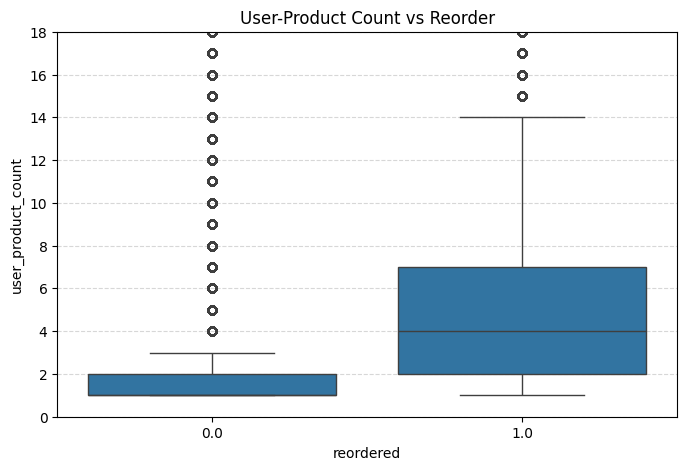

In [14]:
#Create Graphique
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_nextBuy,
    x="reordered",
    y="user_product_count"
)

plt.ylim(0, 15) 
plt.yticks(range(0, 20, 2))
plt.grid(True, axis='y', linestyle="--", alpha=0.5)

plt.title("User-Product Count vs Reorder")
plt.show()

Observation:


Les personne qui on reorder au moins une fois un produit  on de grande chance de la reorder pour plus de la moitié des client cela sera au moins 4 ou plus

Déduction:

Le fait d'avoir racheter un produit au moins une fois, améne trés souvent au réachat de ce produit dans le futur

Insight:

Le rachat d'un produit augemente ça probabilité de rachat, dans le futur on pourrai donc encourager cette tendance

On peut maintenant ce demander comment ces rachat du même produit sont espacer dans le temps.

In [ ]:
#Prépare dataset

df_nextBuy["user_recency"] = (
    df_nextBuy
    .groupby("user_id")["days_since_prior_order"]
    .transform("mean")
)


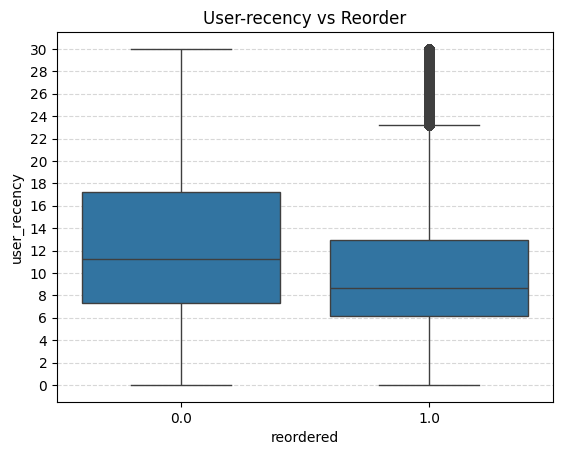

In [24]:
#Graphe
sns.boxplot(
    data=df_nextBuy,
    x="reordered",
    y="user_recency"
)

plt.yticks(range(0, 32, 2))
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.title("User-recency vs Reorder")
plt.show()

Observation:

On constate que la mediane des jour et plus petit quand on a déjà racheter et qu'elle ce situe au alentour des 8 jour

Déduction:

On en déduit que le fait d'avoir déjà acheter plusieurs fois le produit diminue le temps avec le prochain du même produit voir même l'inscrit dans une logique hebdomadaire.

Insigiht:

Insigiht:
On pourrai idendifier les produit acheter de manière hebdomadére par le client et lui facile ces achat voir même proposer des produit similaire ou complémentaire.